#1. IMPOTAÇÃO DAS BIBLIOTECAS

In [50]:

"""
============================================================

OBJETIVO:
Importar todas as bibliotecas utilizadas.

BIBLIOTECAS:

pandas / numpy:
- manipulação dos dados

matplotlib / seaborn:
- visualizações

scikit-learn:
- Machine Learning
- pré-processamento
- métricas
- pipeline
- validação

shap:
- interpretabilidade moderna (XAI)

============================================================
"""

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Pré-processamento
from sklearn.preprocessing import (
    OneHotEncoder,
    MinMaxScaler,
    label_binarize
)

# Tratamento de missing values
from sklearn.impute import SimpleImputer

# Modelo
from sklearn.linear_model import LogisticRegression

# Seleção de features
from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

# Grid Search / Validação
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

# Balanceamento
from sklearn.utils.class_weight import (
    compute_sample_weight
)

# Métricas
from sklearn.metrics import (

    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    top_k_accuracy_score
)

# Calibration
from sklearn.calibration import calibration_curve

# PCA / t-SNE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Explainable AI
import shap

# Utilitário
from sklearn.utils.validation import check_is_fitted

# Configuração visual
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# 2. CARREGAMENTO DOS DADOS

In [51]:
"""
============================================================

OBJETIVO:
Carregar os datasets de treino e teste.

ARQUIVOS:
- datasense_full_train_1sec.parquet
- datasense_full_test_1sec.parquet

IMPORTANTE:
Cada linha representa:
- uma janela temporal
- contendo estatísticas de rede
- relacionadas ao tráfego IIoT

============================================================
"""

df_train = pd.read_parquet(
    "datasense_full_train_1sec.parquet"
)

df_test = pd.read_parquet(
    "datasense_full_test_1sec.parquet"
)

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

Train shape: (170393, 115)
Test shape : (56798, 115)


#3. DEFINIÇÃO DO TARGET

In [52]:
"""
============================================================

OBJETIVO:
Definir o problema multiclasse.

TARGET:
label4

label4:
- contém os cenários completos de ataques
- representa 84 classes distintas

EXEMPLOS:
- benign
- dos_syn-flood
- ddos_udp-flood
- reconnaissance_portscan

============================================================
"""

target_col = "label4"

y_train = df_train[target_col]
y_test = df_test[target_col]

print("Quantidade de classes:")
print(y_train.nunique())

print("\nDistribuição das classes:")
display(y_train.value_counts().head(20))

Quantidade de classes:
84

Distribuição das classes:


label4
benign                             102600
mitm_arp-spoofing                    3148
malware_mirai-udp-flood              3006
recon_os-scan                        2969
recon_vuln-scan                      2956
recon_host-disc-tcp-ack-ping         2952
recon_host-disc-tcp-syn-ping         2945
recon_port-scan                      2939
recon_host-disc-tcp-syn-stealth      2933
recon_host-disc-arp-ping             2927
recon_host-disc-udp-ping             2919
malware_mirai-syn-flood              2647
mitm_ip-spoofing                     2280
recon_ping-sweep                     1663
dos_udp-flood                        1292
dos_icmp-flood                       1289
dos_icmp-frag-flood                  1202
ddos_icmp-flood                      1199
ddos_icmp-frag-flood                 1197
ddos_udp-frag-flood                  1197
Name: count, dtype: int64

#4. REMOÇÃO DE COLUNAS

In [53]:
"""
============================================================

OBJETIVO:
Remover apenas labels auxiliares.

IMPORTANTE:
Nesta versão:
device_name será mantido.

ABORDAGEM:
Context-Aware IDS

============================================================
"""

cols_to_drop = [

    "label1",
    "label2",
    "label3",
    "label4",
    "label_extended"
]

# MANTÉM device_name
# MANTÉM device_type

X_train = df_train.drop(columns=cols_to_drop)
X_test = df_test.drop(columns=cols_to_drop)

print("Quantidade de features:")
print(X_train.shape[1])

print("\nFeatures relacionadas aos dispositivos:")

display(

    [col for col in X_train.columns

     if "device" in col.lower()]
)

Quantidade de features:
110

Features relacionadas aos dispositivos:


['device_name', 'device_type']

#5. IDENTIFICAÇÃO DAS FEATURES

In [54]:
# ============================================================
# CÉLULA 6 — IDENTIFICAÇÃO DAS FEATURES
# ============================================================

"""
============================================================

OBJETIVO:
Separar corretamente:
- features numéricas
- features categóricas

CORREÇÃO:
Evitar colunas categóricas sendo tratadas
como numéricas.

============================================================
"""

# garante cópia
X_train = X_train.copy()
X_test = X_test.copy()

# converte bool para string
for col in X_train.columns:

    if X_train[col].dtype == "bool":

        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)

# features numéricas
numerical_features = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

# todas as outras viram categóricas
categorical_features = [

    col for col in X_train.columns

    if col not in numerical_features
]

print("==================================================")
print("IDENTIFICAÇÃO DAS FEATURES FINALIZADA")
print("==================================================")

print("\nQuantidade de features numéricas:")
print(len(numerical_features))

print("\nQuantidade de features categóricas:")
print(len(categorical_features))

print("\nExemplo de categóricas:")
print(categorical_features[:10])

print("\nExemplo de numéricas:")
print(numerical_features[:10])

IDENTIFICAÇÃO DAS FEATURES FINALIZADA

Quantidade de features numéricas:
64

Quantidade de features categóricas:
46

Exemplo de categóricas:
['device_name', 'network_protocols_src_has_udp', 'network_protocols_src_has_ssh', 'network_protocols_src_has_tcp', 'network_protocols_src_has_http', 'network_protocols_src_has_data', 'network_protocols_src_has_xlm', 'network_protocols_src_has_mqtt', 'network_protocols_src_has_lbtrm', 'network_protocols_src_has_dns']

Exemplo de numéricas:
['network_fragmentation-score', 'network_fragmented-packets', 'network_header-length_avg', 'network_header-length_max', 'network_header-length_min', 'network_header-length_std_deviation', 'network_interval-packets', 'network_ip-flags_avg', 'network_ip-flags_max', 'network_ip-flags_min']


#6. PIPELINE DE PRÉ-PROCESSAMENTO

In [55]:
# ============================================================
# CÉLULA 7 — PIPELINE DE PRÉ-PROCESSAMENTO
# ============================================================

"""
============================================================

OBJETIVO:
Criar pipeline organizada.

ETAPAS:
- imputação
- normalização
- one-hot encoding

============================================================
"""

# Pipeline numérica
numeric_transformer = Pipeline([

    (
        "imputer",

        SimpleImputer(strategy="median")
    ),

    (
        "scaler",

        MinMaxScaler()
    )
])

# Pipeline categórica
categorical_transformer = Pipeline([

    (
        "imputer",

        SimpleImputer(strategy="most_frequent")
    ),

    (
        "onehot",

        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

# Pipeline completa
preprocessor = ColumnTransformer([

    (
        "num",

        numeric_transformer,

        numerical_features
    ),

    (
        "cat",

        categorical_transformer,

        categorical_features
    )
])

print("Pipeline de pré-processamento criada com sucesso.")

print("\nQuantidade de features numéricas:")
print(len(numerical_features))

print("\nQuantidade de features categóricas:")
print(len(categorical_features))

Pipeline de pré-processamento criada com sucesso.

Quantidade de features numéricas:
64

Quantidade de features categóricas:
46


#7. TRANSFORMAÇÃO DOS DADOS

In [56]:
"""
============================================================

OBJETIVO:
Aplicar preprocessamento.

============================================================
"""

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("Shape após preprocessamento:")
print(X_train_processed.shape)

Shape após preprocessamento:
(170393, 190)


#8. FEATURE SELECTION

In [57]:
"""
============================================================

OBJETIVO:
Selecionar melhores features.

MÉTODO:
Mutual Information

JUSTIFICATIVA:
- funciona com variáveis contínuas
- detecta relações não-lineares
- muito usado em IDS

============================================================
"""

selector = SelectKBest(

    score_func=mutual_info_classif,

    k=180
)

X_train_selected = selector.fit_transform(

    X_train_processed,

    y_train
)

X_test_selected = selector.transform(
    X_test_processed
)

print("Quantidade final de features:")
print(X_train_selected.shape[1])

Quantidade final de features:
180


#9. ANÁLISE DAS FEATURES

In [58]:
"""
============================================================

OBJETIVO:
Analisar:
- features selecionadas
- importância estatística

============================================================
"""

feature_names = (
    preprocessor.get_feature_names_out()
)

selected_mask = selector.get_support()

selected_features = feature_names[
    selected_mask
]

scores = selector.scores_[selected_mask]

feature_importance = pd.DataFrame({

    "Feature": selected_features,

    "Mutual_Information": scores
})

feature_importance = feature_importance.sort_values(

    by="Mutual_Information",

    ascending=False
)

display(feature_importance.head(20))

,Feature,Mutual_Information
10,num__network_ip-length_avg,1.075199
29,num__network_packets_dst_count,0.989365
28,num__network_packets_all_count,0.989318
5,num__network_interval-packets,0.971198
59,num__network_window-size_avg,0.907806
51,num__network_time-delta_avg,0.878395
35,num__network_ports_all_count,0.842828
55,num__network_ttl_avg,0.836585
37,num__network_ports_src_count,0.831135
47,num__network_tcp-flags_avg,0.825951


#10. VISUALIZAÇÃO DAS FEATURES

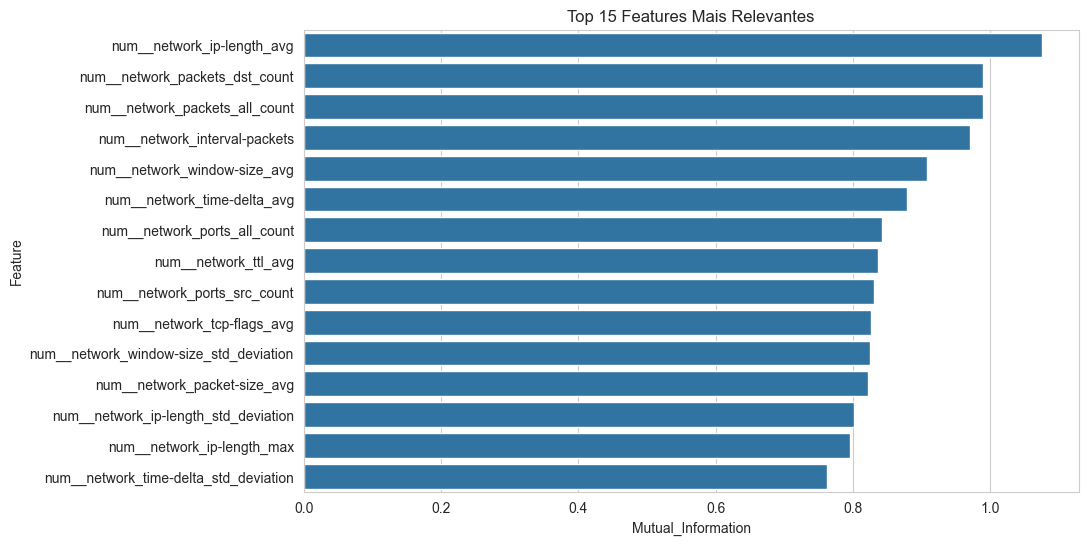

In [59]:
"""
============================================================

OBJETIVO:
Visualizar top features.

============================================================
"""

plt.figure(figsize=(10,6))

sns.barplot(

    data=feature_importance.head(15),

    x="Mutual_Information",

    y="Feature"
)

plt.title(
    "Top 15 Features Mais Relevantes"
)

plt.show()

#11. SAMPLE WEIGHT

In [60]:
"""
============================================================

OBJETIVO:
Balancear automaticamente as classes.

============================================================
"""

sample_weight = compute_sample_weight(

    class_weight="balanced",

    y=y_train
)

print("Sample weights calculados.")

Sample weights calculados.


#12. DEFINIÇÃO DO MODELO

In [61]:
"""
============================================================

OBJETIVO:
Criar Logistic Regression Multiclasse.

============================================================
"""

model = LogisticRegression(

    max_iter=3000,

    C=1.0,

    tol=1e-3,

    random_state=42
)

print("Modelo Logistic Regression criado com sucesso.")

Modelo Logistic Regression criado com sucesso.


#13. GRID SEARCH

In [62]:
"""
============================================================

OBJETIVO:
Buscar melhores hiperparâmetros.

MÉTRICA:
F1 Macro

============================================================
"""

param_grid = {

    "C": [0.3, 0.7, 1.0]
}

cv = StratifiedKFold(

    n_splits=3,

    shuffle=True,

    random_state=42
)

grid = GridSearchCV(

    estimator=model,

    param_grid=param_grid,

    scoring="f1_macro",

    cv=cv,

    n_jobs=-1,

    verbose=2,

    return_train_score=True
)

grid.fit(

    X_train_selected,

    y_train,

    sample_weight=sample_weight
)

print("Melhores parâmetros:")
print(grid.best_params_)

print("\nMelhor F1 Macro:")
print(grid.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Melhores parâmetros:
{'C': 1.0}

Melhor F1 Macro:
0.7078875716089348


#14. PREDIÇÃO MULTICLASSE

In [63]:
"""
============================================================

OBJETIVO:
Executar:
- predições
- probabilidades
- análise de confiança

============================================================
"""

best_model = grid.best_estimator_

check_is_fitted(best_model)

# probabilidades
y_prob = best_model.predict_proba(
    X_test_selected
)

# predição final
y_pred = best_model.predict(
    X_test_selected
)

# classes
classes = best_model.classes_

# maior probabilidade
max_prob = np.max(y_prob, axis=1)

# segunda maior probabilidade
sorted_probs = np.sort(y_prob, axis=1)

second_best_prob = sorted_probs[:, -2]

# margem de confiança
confidence_margin = (

    max_prob -

    second_best_prob
)

# dataframe final
df_result = pd.DataFrame({

    "Classe_Real": y_test.values,

    "Classe_Predita": y_pred,

    "Probabilidade_Maxima": max_prob,

    "Segunda_Probabilidade": second_best_prob,

    "Margem_Confianca": confidence_margin
})

# correto/incorreto
df_result["Correto"] = (

    df_result["Classe_Real"]

    ==

    df_result["Classe_Predita"]
)

print("Quantidade total:")
print(len(df_result))

print("\nPredições corretas:")
print(df_result["Correto"].sum())

print("\nPredições incorretas:")
print((~df_result["Correto"]).sum())

display(df_result.head())

Quantidade total:
56798

Predições corretas:
22152

Predições incorretas:
34646


,Classe_Real,Classe_Predita,Probabilidade_Maxima,Segunda_Probabilidade,Margem_Confianca,Correto
0,benign,dos_http-flood-port-443,0.544561,0.227658,0.316903,False
1,benign,ddos_synonymousip-flood-port-80,0.494339,0.051928,0.442411,False
2,benign,dos_http-flood-port-6668,0.220494,0.164278,0.056217,False
3,recon_host-disc-tcp-ack-ping,recon_vuln-scan,0.150564,0.138259,0.012305,False
4,benign,recon_ping-sweep,0.144156,0.106211,0.037945,False


#15. AMOSTRAS MAIS CONFIANTES

In [64]:
"""
============================================================

OBJETIVO:
Mostrar amostras com maior confiança.

============================================================
"""

mais_confiantes = df_result.sort_values(

    by="Probabilidade_Maxima",

    ascending=False
)

display(
    mais_confiantes.head(20)
)

,Classe_Real,Classe_Predita,Probabilidade_Maxima,Segunda_Probabilidade,Margem_Confianca,Correto
36141,web_command-injection,web_command-injection,1.000000,4.969597e-08,1.000000,True
25368,web_backdoor-upload,web_backdoor-upload,1.000000,3.054026e-08,1.000000,True
27714,dos_http-flood-port-443,dos_http-flood-port-443,1.000000,4.920323e-08,1.000000,True
29550,web_backdoor-upload,web_backdoor-upload,1.000000,1.741080e-07,1.000000,True
1847,recon_os-scan,recon_os-scan,0.999999,2.421529e-07,0.999999,True
44672,recon_os-scan,recon_os-scan,0.999999,2.989741e-07,0.999999,True
40386,recon_os-scan,recon_os-scan,0.999999,2.911041e-07,0.999999,True
41822,recon_os-scan,recon_os-scan,0.999999,3.195063e-07,0.999998,True
8766,recon_os-scan,recon_os-scan,0.999999,3.419030e-07,0.999998,True
29574,dos_http-flood-port-554,dos_http-flood-port-554,0.999999,1.255788e-06,0.999997,True


#16. AMOSTRAS MAIS INCERTAS

In [65]:
"""
============================================================

OBJETIVO:
Mostrar amostras mais difíceis.

============================================================
"""

mais_incertas = df_result.sort_values(

    by="Margem_Confianca",

    ascending=True
)

display(
    mais_incertas.head(20)
)

,Classe_Real,Classe_Predita,Probabilidade_Maxima,Segunda_Probabilidade,Margem_Confianca,Correto
51078,recon_port-scan,recon_host-disc-tcp-syn-ping,0.134859,0.134858,0.000001,False
45621,recon_host-disc-udp-ping,recon_vuln-scan,0.139580,0.139573,0.000007,False
19727,recon_host-disc-tcp-ack-ping,recon_vuln-scan,0.140023,0.140015,0.000007,False
39111,recon_host-disc-arp-ping,recon_vuln-scan,0.134866,0.134857,0.000010,False
10248,recon_host-disc-arp-ping,recon_vuln-scan,0.134884,0.134873,0.000010,False
20829,recon_host-disc-udp-ping,recon_os-scan,0.157090,0.157077,0.000013,False
6222,recon_port-scan,recon_vuln-scan,0.133566,0.133551,0.000015,False
36201,recon_host-disc-udp-ping,recon_host-disc-tcp-syn-ping,0.130040,0.130021,0.000018,False
47921,recon_host-disc-udp-ping,recon_host-disc-udp-ping,0.140902,0.140883,0.000019,True
56389,recon_vuln-scan,ddos_slowloris-port-1883,0.201900,0.201878,0.000022,False


#17. MÉTRICAS

In [66]:
"""
============================================================

OBJETIVO:
Avaliar desempenho do modelo.

============================================================
"""

print("Accuracy:")
print(
    accuracy_score(y_test, y_pred)
)

print("\nF1 Macro:")
print(
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print("\nF1 Weighted:")
print(
    f1_score(
        y_test,
        y_pred,
        average="weighted"
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0

    )
)

Accuracy:
0.39001373287791824

F1 Macro:
0.556596279519661

F1 Weighted:
0.46861208038096436

Classification Report:
                                   precision    recall  f1-score   support

                           benign       0.90      0.31      0.46     34200
        bruteforce_dictionary-ssh       0.52      0.43      0.47       240
     bruteforce_dictionary-telnet       0.13      0.72      0.23       225
    ddos_ack-frag-flood-port-1883       0.72      0.84      0.77       232
      ddos_ack-frag-flood-port-80       0.63      0.74      0.68       168
               ddos_connect-flood       0.30      0.87      0.45        15
        ddos_http-flood-port-1883       0.67      0.78      0.72       225
          ddos_http-flood-port-80       0.69      0.72      0.70       167
                  ddos_icmp-flood       0.93      0.76      0.84       400
             ddos_icmp-frag-flood       0.85      0.75      0.80       395
          ddos_mqtt-publish-flood       0.92      0.80   

#18. TOP-K ACCURACY

In [67]:
"""
============================================================

OBJETIVO:
Avaliar:
- Top-1
- Top-3
- Top-5

============================================================
"""

top1 = top_k_accuracy_score(

    y_test,

    y_prob,

    k=1,

    labels=classes
)

top3 = top_k_accuracy_score(

    y_test,

    y_prob,

    k=3,

    labels=classes
)

top5 = top_k_accuracy_score(

    y_test,

    y_prob,

    k=5,

    labels=classes
)

print("Top-1 Accuracy:", top1)
print("Top-3 Accuracy:", top3)
print("Top-5 Accuracy:", top5)

Top-1 Accuracy: 0.39001373287791824
Top-3 Accuracy: 0.6298989401035248
Top-5 Accuracy: 0.8322476143526181


#19. ROC-AUC MULTICLASSE

In [68]:
"""
============================================================

OBJETIVO:
ROC-AUC One-vs-Rest multiclasses.

============================================================
"""

y_test_bin = label_binarize(

    y_test,

    classes=classes
)

roc_auc_macro = roc_auc_score(

    y_test_bin,

    y_prob,

    average="macro",

    multi_class="ovr"
)

roc_auc_weighted = roc_auc_score(

    y_test_bin,

    y_prob,

    average="weighted",

    multi_class="ovr"
)

print("ROC-AUC Macro:")
print(roc_auc_macro)

print("\nROC-AUC Weighted:")
print(roc_auc_weighted)

ROC-AUC Macro:
0.9671666469170064

ROC-AUC Weighted:
0.9122204667417386


#20. MATRIZ DE CONFUSÃO

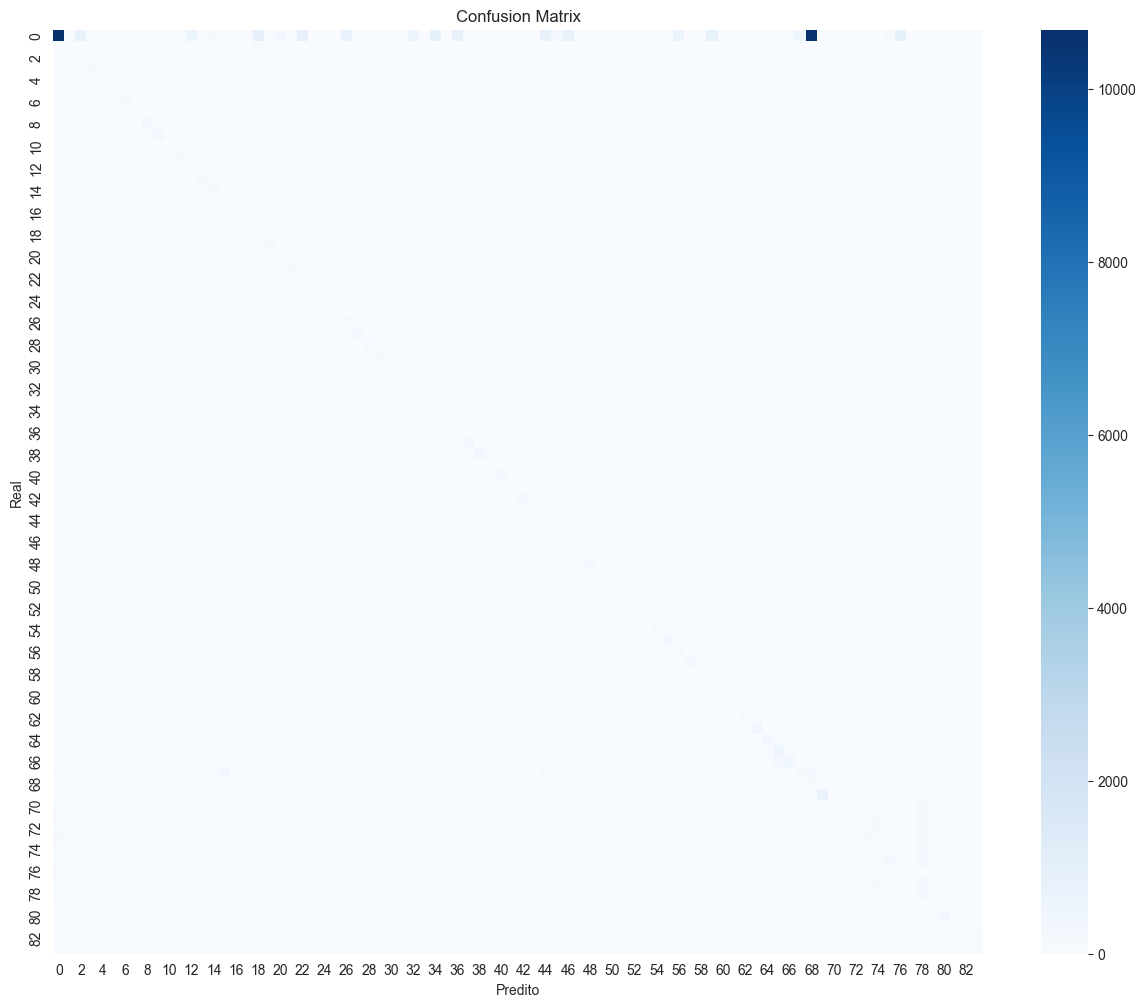

In [69]:
"""
============================================================

OBJETIVO:
Visualizar erros do modelo.

============================================================
"""

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(15,12))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()

#21. CLASSES MAIS CONFUNDIDAS

In [70]:
"""
============================================================

OBJETIVO:
Encontrar ataques mais confundidos.

============================================================
"""

confusions = []

for i in range(len(classes)):

    for j in range(len(classes)):

        if i != j:

            confusions.append({

                "Classe_Real": classes[i],

                "Classe_Predita": classes[j],

                "Quantidade": cm[i, j]
            })

conf_df = pd.DataFrame(confusions)

conf_df = conf_df.sort_values(

    by="Quantidade",

    ascending=False
)

display(conf_df.head(20))

,Classe_Real,Classe_Predita,Quantidade
67,benign,mitm_impersonation,10598
33,benign,dos_http-flood-port-6668,957
75,benign,recon_ping-sweep,921
21,benign,ddos_synonymousip-flood-port-80,902
17,benign,ddos_slowloris-port-8000,879
58,benign,dos_tcp-flood-port-23,871
45,benign,dos_slowloris-port-80,829
1,benign,bruteforce_dictionary-telnet,777
35,benign,dos_http-flood-port-9595,755
43,benign,dos_slowloris-port-1883,753


#22. PCA

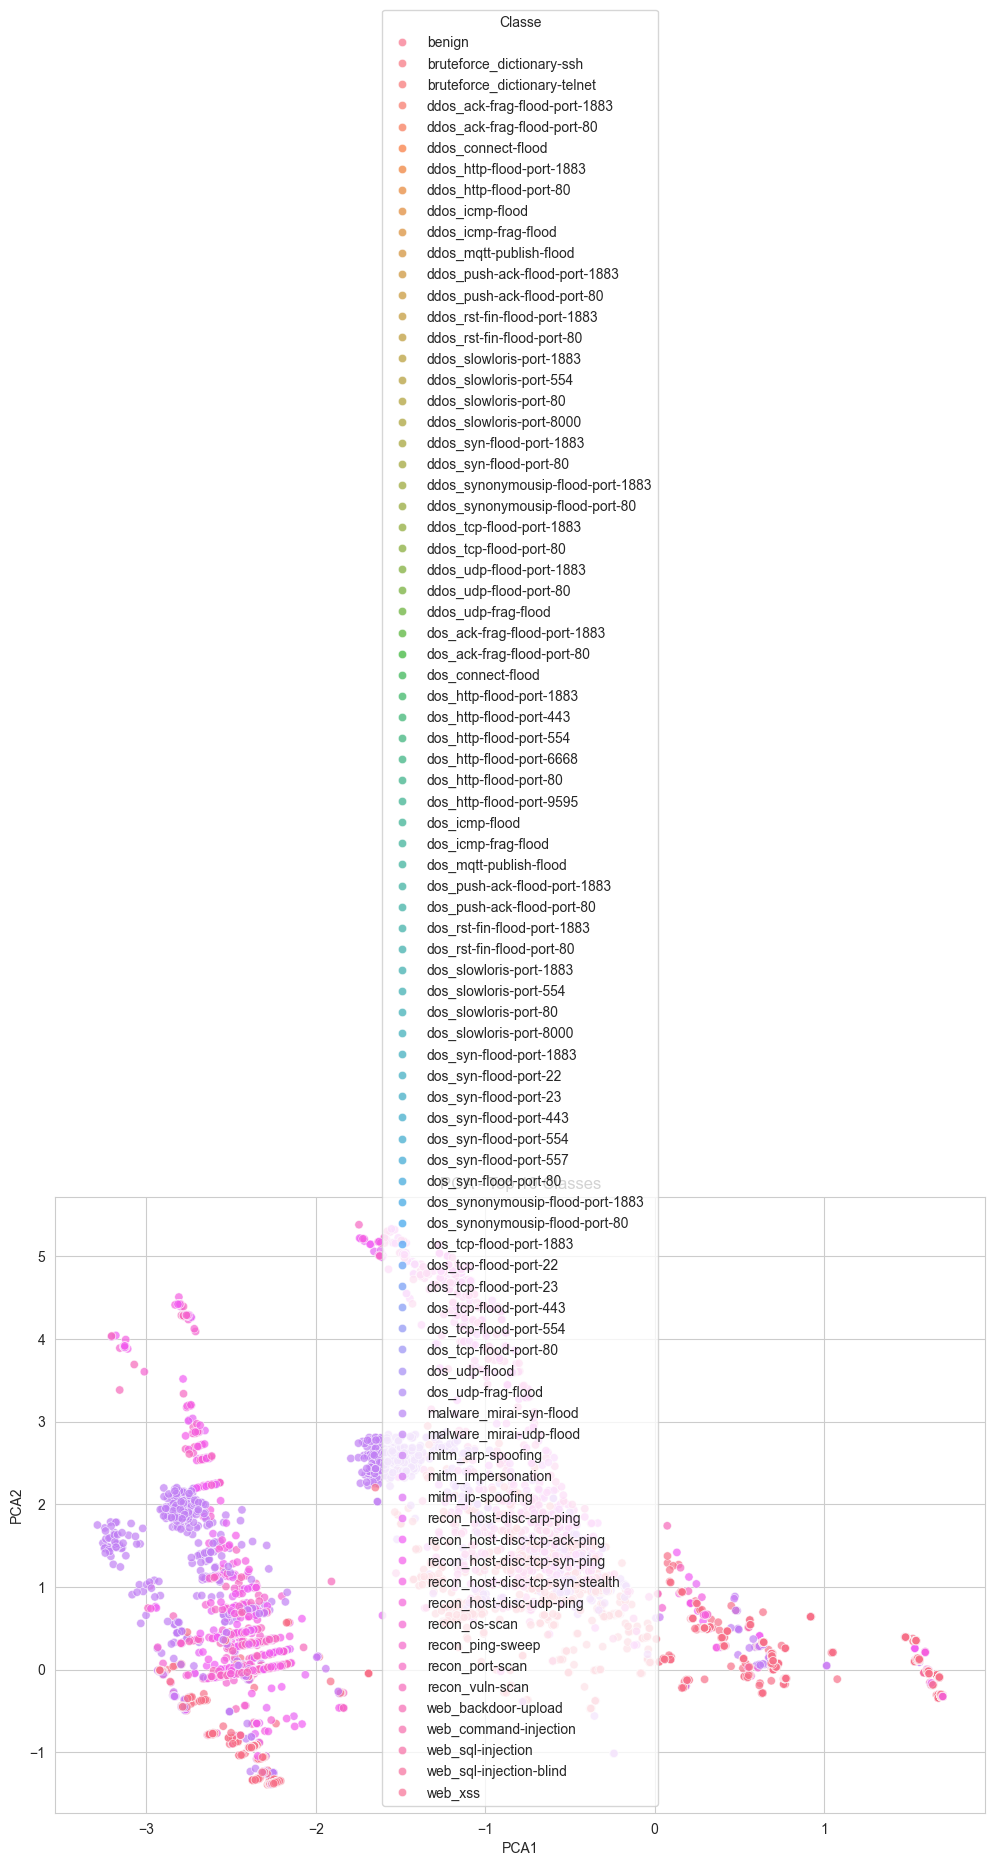

In [71]:
"""
============================================================

OBJETIVO:
Visualização PCA.

============================================================
"""

pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_test_selected
)

df_pca = pd.DataFrame({

    "PCA1": X_pca[:,0],

    "PCA2": X_pca[:,1],

    "Classe": y_test.values
})

top_classes = (
    y_test.value_counts()
    .head(10)
    .index
)

df_plot = df_pca[
    df_pca["Classe"].isin(top_classes)
]

plt.figure(figsize=(12,8))

sns.scatterplot(

    data=df_plot,

    x="PCA1",

    y="PCA2",

    hue="Classe",

    alpha=0.7
)

plt.title("PCA - Top 10 Classes")

plt.show()

#24. t-SNE

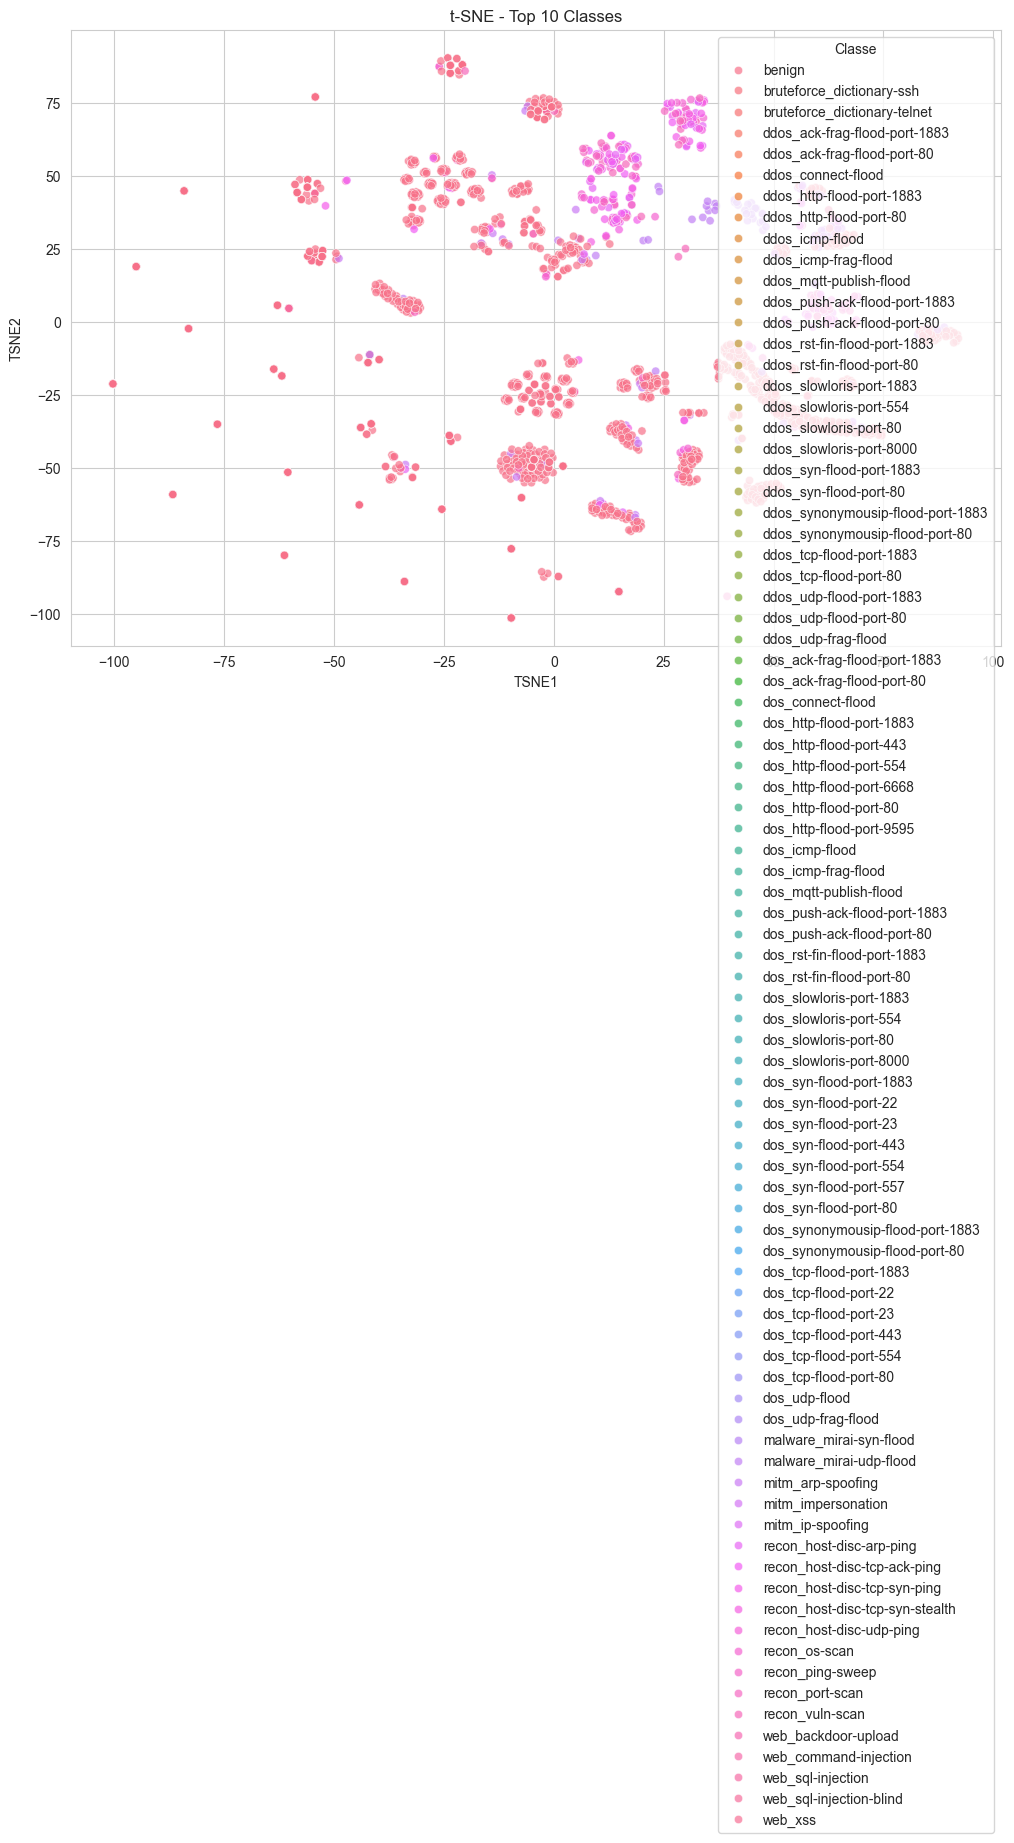

In [72]:
"""
============================================================

OBJETIVO:
Visualização não-linear das classes.

============================================================
"""

sample_size = 3000

X_tsne_sample = X_test_selected[:sample_size]

y_tsne_sample = y_test.iloc[:sample_size]

tsne = TSNE(

    n_components=2,

    perplexity=30,

    random_state=42
)

X_tsne = tsne.fit_transform(
    X_tsne_sample
)

df_tsne = pd.DataFrame({

    "TSNE1": X_tsne[:,0],

    "TSNE2": X_tsne[:,1],

    "Classe": y_tsne_sample.values
})

top_classes = (
    y_test.value_counts()
    .head(10)
    .index
)

df_plot = df_tsne[
    df_tsne["Classe"].isin(top_classes)
]

plt.figure(figsize=(12,8))

sns.scatterplot(

    data=df_plot,

    x="TSNE1",

    y="TSNE2",

    hue="Classe",

    alpha=0.7
)

plt.title("t-SNE - Top 10 Classes")

plt.show()

#25. SHAP VALUES

c:\Users\bruno.lima\Documents\Projeto IIoT Multiclasse\venv\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


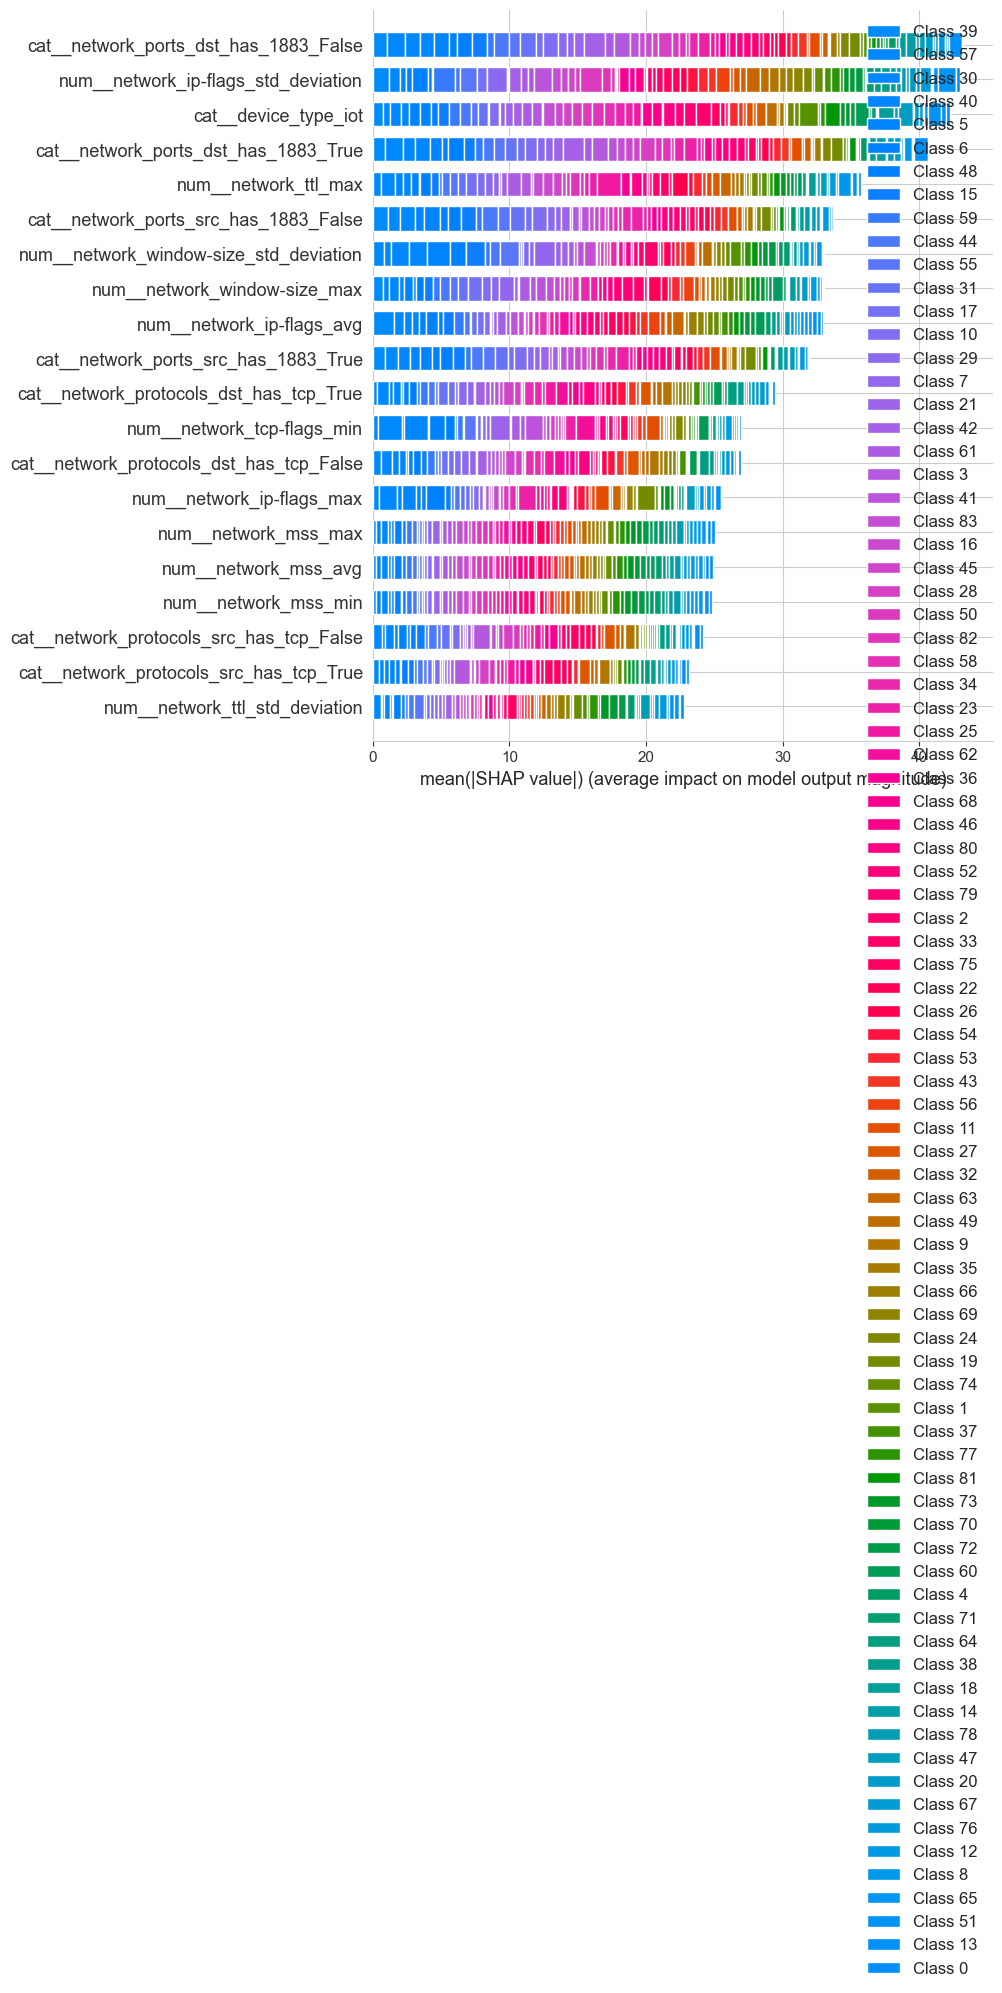

In [73]:
"""
============================================================

OBJETIVO:
Interpretabilidade do modelo.

============================================================
"""

sample_size = 1000

X_sample = X_test_selected[:sample_size]

explainer = shap.Explainer(

    best_model,

    X_sample
)

shap_values = explainer(X_sample)

shap.summary_plot(

    shap_values,

    X_sample,

    feature_names=selected_features
)